In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:



import jax
import jax.numpy as jnp

# Set device to CPU
jax.config.update("jax_platform_name", "cpu")

import matplotlib.pyplot as plt

In [3]:
from probjax.inference.filtering.kalman_filter import kalman_filter
from probjax.utils.linalg import matrix_fraction_decomposition

In [4]:
# Define the model
A = jnp.array([[0., -2.], [1/5., -0.]])
B = jnp.array([[0.1, 0.0], [0.0, 0.1]])
C = jnp.eye(2)
D = jnp.eye(2)

dt = 0.1

transition_matrix, transtion_cov = matrix_fraction_decomposition(0,dt,A, B)

mu0 = jnp.array([0.1, -0.1])
C0 = jnp.array([[0.1, 0.0], [0.0, 0.1]])

In [6]:
kernel = kalman_filter(transition_matrix, transtion_cov, C,D)

In [7]:
state = kernel.init(mu0, C0, 0.)

In [8]:
from probjax.inference.filter import filter

In [9]:
ts = jnp.linspace(0, 20, 200)
states, info = filter(jax.random.PRNGKey(0), ts, jnp.array([100.]), jnp.array([0.,0.]), kernel, mu0, C0)

In [10]:
states

KalmanFilterState(mean=Array([[ 1.19786739e-01, -9.78013948e-02],
       [ 1.39094487e-01, -9.52117145e-02],
       [ 1.57846034e-01, -9.22413170e-02],
       [ 1.75966412e-01, -8.89020786e-02],
       [ 1.93383157e-01, -8.52073506e-02],
       [ 2.10026622e-01, -8.11719000e-02],
       [ 2.25830272e-01, -7.68118724e-02],
       [ 2.40730897e-01, -7.21447021e-02],
       [ 2.54668921e-01, -6.71890527e-02],
       [ 2.67588615e-01, -6.19647317e-02],
       [ 2.79438317e-01, -5.64926341e-02],
       [ 2.90170640e-01, -5.07946424e-02],
       [ 2.99742669e-01, -4.48935404e-02],
       [ 3.08116108e-01, -3.88129242e-02],
       [ 3.15257490e-01, -3.25771086e-02],
       [ 3.21138293e-01, -2.62110271e-02],
       [ 3.25734943e-01, -1.97401363e-02],
       [ 3.29029113e-01, -1.31903123e-02],
       [ 3.31007600e-01, -6.58774422e-03],
       [ 3.31662476e-01,  4.11664842e-05],
       [ 3.30991149e-01,  6.66991249e-03],
       [ 3.28996301e-01,  1.32719874e-02],
       [ 3.25685918e-01,  1.982

In [11]:
mean = states.mean
cov = states.cov
std = jax.vmap(jnp.linalg.cholesky)(cov)

ValueError: x and y must have same first dimension, but have shapes (200,) and (199,)

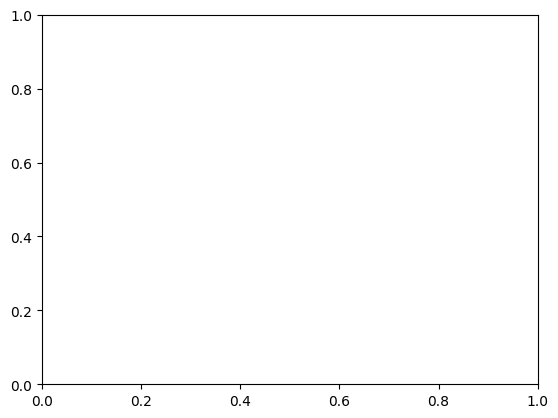

In [12]:
plt.plot(ts,mean[:,0])
plt.fill_between(ts, mean[:,0] - std[:,0,0], states.mean[:,0] + std[:,0,0], alpha=0.2)

plt.plot(ts,mean[:,1])
plt.fill_between(ts, states.mean[:,1] - std[:,1,1], states.mean[:,1] + std[:,1,1], alpha=0.2)

In [292]:
from probjax.inference.filtering.uncented_kalman_filter import ukf

In [17]:
# Jax 64 bit precision
import jax

# Enable 64 bit
jax.config.update("jax_enable_x64", True)



In [18]:
def transition_fn(x, t_old, t):
    return jnp.dot(A, x)

def observation_fn(x, t):
    return jnp.dot(C, x)


In [21]:
from probjax.inference.filtering.uncented_kalman_filter import ukf 
kernel = ukf(transition_fn, B*0, observation_fn, D)

In [22]:
mu0 = mu0.astype(jnp.float64)
C0 = C0.astype(jnp.float64)

In [23]:
state = kernel.init(mu0, C0, 0.)

In [24]:
ts = jnp.linspace(0, 20, 200)
states, info = filter(jax.random.PRNGKey(0), ts, jnp.array([100.]), jnp.array([0.,0.]), kernel, mu0, C0)

In [25]:
mean = states.mean
cov = states.cov
std = jax.vmap(jnp.linalg.cholesky)(cov)

ValueError: x and y must have same first dimension, but have shapes (200,) and (199,)

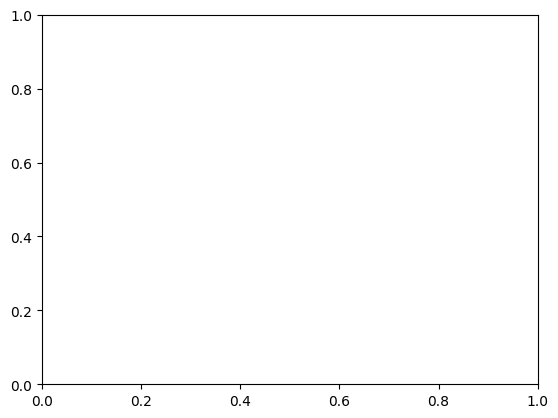

In [27]:
plt.plot(ts,mean[:,0])
plt.fill_between(ts, mean[:,0] - std[:,0,0], states.mean[:,0] + std[:,0,0], alpha=0.2)

plt.plot(ts,mean[:,1])
plt.fill_between(ts, states.mean[:,1] - std[:,1,1], states.mean[:,1] + std[:,1,1], alpha=0.2)